In [1]:
import pandas as pd

df = pd.read_csv("/content/sample_data/Student_Performance.csv")

print(df.head())
print(df.info())
print(df.shape)

   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

  study_method  math_score  science_score  english_score  overall_score  \
0        notes        42.7           55.4           5

In [2]:
print(df.describe())

print("Average Overall Score:",
      df["overall_score"].mean())

print("Average Attendance:",
      df["attendance_percentage"].mean())

print("Average Study Hours:",
      df["study_hours"].mean())

        student_id           age   study_hours  attendance_percentage  \
count  25000.00000  25000.000000  25000.000000           25000.000000   
mean    7493.04380     16.482760      4.253224              75.084084   
std     4323.56215      1.703895      2.167541              14.373171   
min        1.00000     14.000000      0.500000              50.000000   
25%     3743.75000     15.000000      2.400000              62.800000   
50%     7461.50000     16.000000      4.300000              75.100000   
75%    11252.00000     18.000000      6.100000              87.500000   
max    15000.00000     19.000000      8.000000             100.000000   

         math_score  science_score  english_score  overall_score  
count  25000.000000   25000.000000   25000.000000   25000.000000  
mean      63.785944      63.745320      63.681948      64.006172  
std       20.875262      20.970529      20.792693      18.932025  
min        0.000000       0.000000       0.000000      14.500000  
25%    

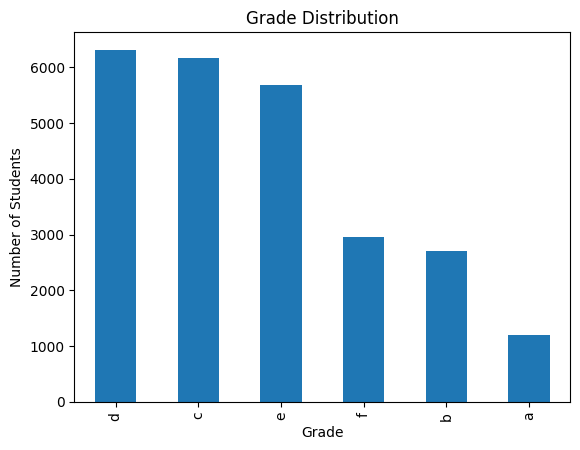

In [3]:
import matplotlib.pyplot as plt

df["final_grade"].value_counts().plot(
    kind="bar"
)

plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Number of Students")

plt.show()

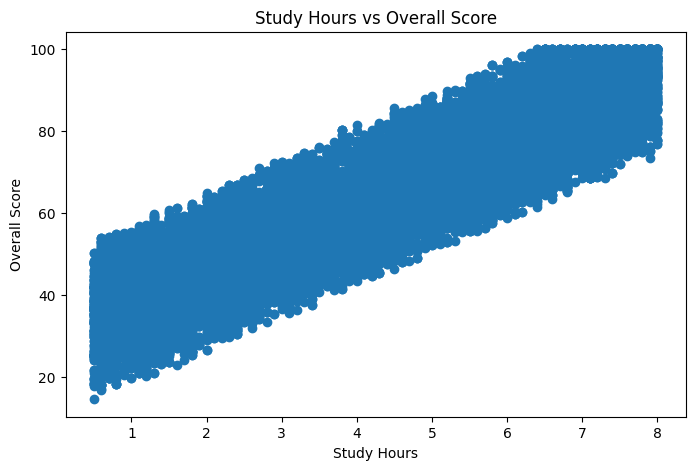

In [4]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["study_hours"],
    df["overall_score"]
)

plt.xlabel("Study Hours")
plt.ylabel("Overall Score")
plt.title("Study Hours vs Overall Score")

plt.show()

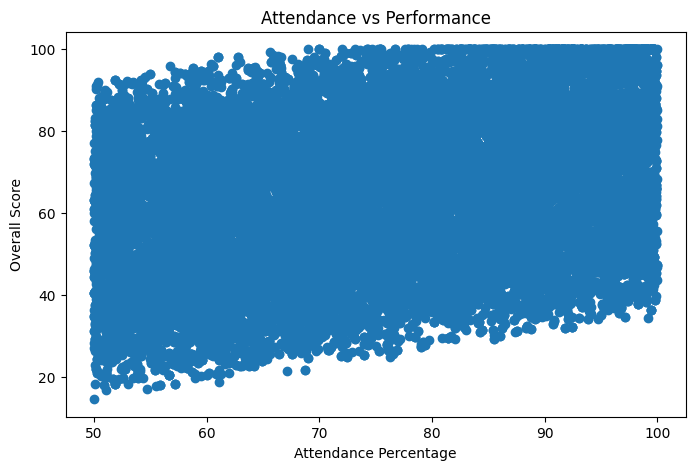

In [5]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["attendance_percentage"],
    df["overall_score"]
)

plt.xlabel("Attendance Percentage")
plt.ylabel("Overall Score")
plt.title("Attendance vs Performance")

plt.show()

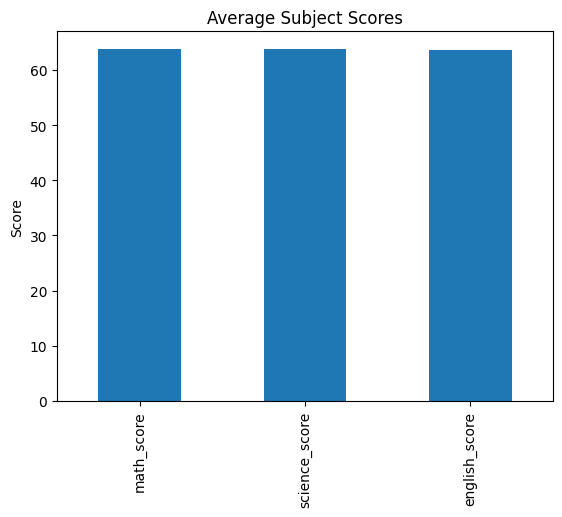

In [6]:
subjects = [
    "math_score",
    "science_score",
    "english_score"
]

avg_scores = df[subjects].mean()

avg_scores.plot(kind="bar")

plt.title("Average Subject Scores")
plt.ylabel("Score")

plt.show()

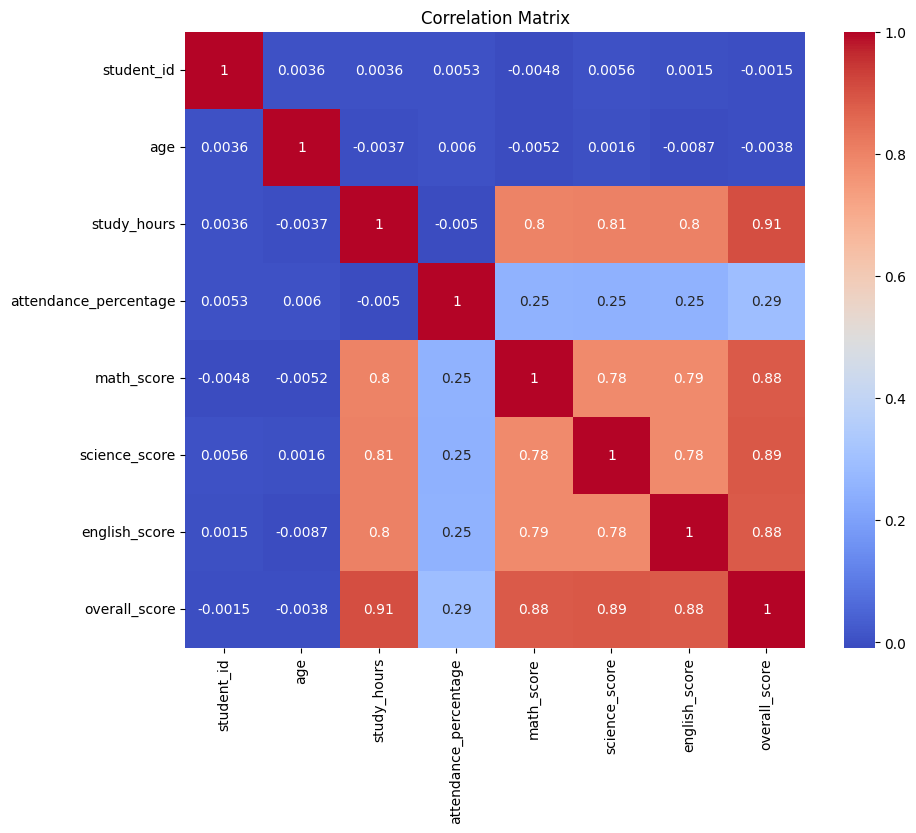

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [8]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X = df[
    [
        "study_hours",
        "attendance_percentage",
        "math_score",
        "science_score",
        "english_score"
    ]
]

y = df["overall_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:",
      mean_absolute_error(y_test, predictions))

MAE: 3.3547411543984604


In [9]:
new_student = [[
    5,      # study hours
    90,     # attendance
    80,     # math
    75,     # science
    85      # english
]]

prediction = model.predict(new_student)

print(
    "Predicted Overall Score:",
    prediction[0]
)

Predicted Overall Score: 78.16566860992602


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[
    [
        "study_hours",
        "attendance_percentage",
        "math_score",
        "science_score",
        "english_score"
    ]
]

y = df["final_grade"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, pred)
)

Accuracy: 0.8732


In [12]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 93.5 MB/s eta 0:00:00


In [13]:
import streamlit as st
import pandas as pd
st.title("Student Performance Dashboard")

st.subheader("Dataset Preview")
st.dataframe(df.head())

st.subheader("Grade Distribution")
st.bar_chart(
    df["final_grade"].value_counts()
)

st.subheader("Overall Score Statistics")
st.write(
    df["overall_score"].describe()
)

st.subheader("Attendance Statistics")
st.write(
    df["attendance_percentage"].describe()
)

2026-06-16 16:07:01.120 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:07:01.456 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-16 16:07:01.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:07:01.457 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:07:01.459 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:07:01.461 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:07:01.463 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:07:01.510 Thread 'MainThread': mi

In [16]:
%%writefile app.py

import streamlit as st
import pandas as pd

df = pd.read_csv("/content/sample_data/Student_Performance.csv")

st.title("Student Performance Dashboard")

st.subheader("Dataset Preview")
st.dataframe(df.head())

st.subheader("Grade Distribution")
st.bar_chart(df["final_grade"].value_counts())

st.subheader("Overall Score Statistics")
st.write(df["overall_score"].describe())

Writing app.py


In [ ]:
!streamlit run app.py



2026-06-16 16:10:11.044 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.119.109.236:8501

